In [1]:
from numba import njit

@njit
def add_samples_to_map(tod, pixel_indexes, accum_map, hit_count_map):
    ndet, nsample = tod.shape

    for det_idx in range(ndet):
        for sample_idx in range(nsample):
            pix_idx = pixel_indexes[sample_idx]
            accum_map[pix_idx] += tod[det_idx, sample_idx]
            hit_count_map[pix_idx] += 1

@njit
def normalize_map(accum_map, hit_count_map):

    for pix_idx in range(len(accum_map)):
        if hit_count_map[pix_idx] > 0:
            accum_map[pix_idx] /= hit_count_map[pix_idx]

Numero di osservazioni: 730


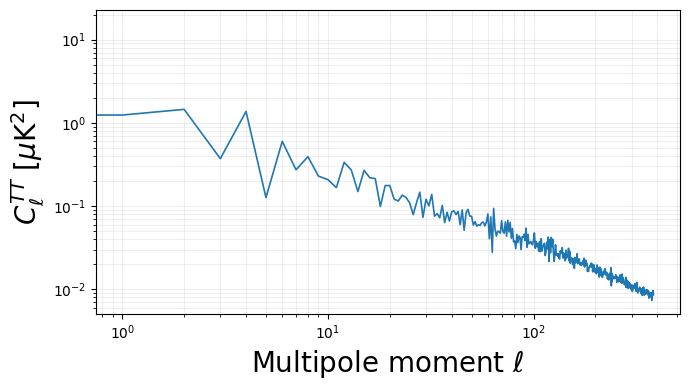

CPU times: user 14min 10s, sys: 25.3 s, total: 14min 36s
Wall time: 3min 51s


In [2]:
%%time

import sys, os
sys.path.append(os.path.abspath("../mylib_project"))

from mylib import add_OofaNoise
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from uuid import UUID
import litebird_sim as lbs


nside = 2**7
start_time = 0
chunk_length = 3600 * 12
number_of_days = 365
duration_s = 86400 * number_of_days
num_of_observations = duration_s // chunk_length
lmax = 3*nside-1



# SIMULATION, SCANNING STRATEGY, DETECTOR

sim = lbs.Simulation(
    start_time=start_time,
    duration_s=duration_s,
    random_seed=12345,
    imo=lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION)
)

sim.set_scanning_strategy(
    lbs.SpinningScanningStrategy.from_imo(
        imo=lbs.Imo(lbs.PTEP_IMO_LOCATION), 
        url=UUID("117fd641-a925-4eeb-9fda-f7c468682108")
    ),
    delta_time_s=120.0
)

instrument = lbs.InstrumentInfo(
    boresight_rotangle_rad=0.0,
    spin_boresight_angle_rad=np.deg2rad(90),
    spin_rotangle_rad=np.deg2rad(75)
)
sim.set_instrument(instrument)

det = lbs.DetectorInfo(
    name="Boresight_detector",
    sampling_rate_hz=20.0, 
    bandcenter_ghz=100.0,
    net_ukrts=50.0,
    fknee_mhz=500.0,
    fmin_hz=1e-5,
    alpha=1
)



# OBSERVATION

sim.create_observations(detectors=det, num_of_obs_per_detector=num_of_observations, allocate_tod=False)

tod = np.empty((1, int(det.sampling_rate_hz * chunk_length)))
T_accum_map = np.zeros(hp.nside2npix(nside))
hit_count_map = np.zeros(len(T_accum_map), dtype='int64')

for obs_idx, cur_obs in enumerate(sim.observations):
    # POINTINGS
    lbs.prepare_pointings(cur_obs, instrument, sim.spin2ecliptic_quats)
    pointings, _ = cur_obs.get_pointings("all")
    
    theta = pointings[0, :, 0]
    phi   = pointings[0, :, 1]
    pixidx = hp.ang2pix(nside, theta, phi)
    
    # NOISE
    tod[:, :] = 0.0
    add_OofaNoise(tod, det, block_duration_s=chunk_length)
    add_samples_to_map(tod, pixidx, T_accum_map, hit_count_map)    


normalize_map(T_accum_map, hit_count_map)

print(f"Numero di osservazioni: {num_of_observations}")


almT = hp.map2alm(T_accum_map, lmax=lmax)
clTT = hp.alm2cl(almT)

clTT_uK2 = clTT * 1e12 

ell = np.arange(len(clTT))

# PLOT
plt.figure(figsize=(7, 4))
plt.loglog(ell, clTT_uK2, linewidth=1.2)
plt.xlabel(r'Multipole moment $\ell$', fontsize=20)
plt.ylabel(r'$C_\ell^{TT} \ [\mu\text{K}^2]$', fontsize=20)
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig("graph_psTT_oofa.pdf")
plt.show()